# Time series analysis

In [2]:
%pip install matplotlib
%pip install numpy
%pip install scikit-image
%pip install scipy
%pip install tifffile
%pip install imagecodecs
%pip install pandas
%pip install seaborn

In [3]:
from pathlib import Path


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import seaborn as sns

import numpy as np
import pandas as pd

import skimage
import tifffile

In [26]:
def overlay(image=None, label_mask=None, df=None, id_col=None, measurement_col=None,
            alpha=0.3, cmap=None, figsize=(8, 8), vmin=None, vmax=None, coordinates=None):
    """
    Overlay a segmentation mask on an image, color-coded by a measurement.

    Parameters
    ----------
    image : 2D/3D numpy array, list of arrays, or None
        Single image, or list of 1-3 images composited as colored channels:
        1 image: grey | 2: red + cyan | 3: magenta + cyan + yellow.
    label_mask : 2D numpy array, list of arrays, or None
        Single mask (integer IDs, background=0), or list of binary/label masks
        each shown in a distinct color. If None, only the image is shown.
    df : pd.DataFrame, optional
        Table with cell IDs and measurements. If None and label_mask is a single
        array, cells are shown with random colors and labeled by ID.
    id_col : str, optional
        Column in df with cell IDs matching label_mask values.
    measurement_col : str or None
        Column to color cells by (categorical or continuous).
    alpha : float
        Overlay opacity (0 = transparent, 1 = opaque).
    cmap : str or None
        Colormap. Defaults: categorical='tab10', continuous='viridis'.
    figsize : tuple
        Figure size in inches.
    vmin, vmax : float or None
        Continuous colormap range. Defaults to data min/max.
    coordinates : (N, 2) array or None
        Dot locations in (row, col) / (y, x) order to plot on top of the image.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    def _normalize(img):
        img = img.astype(float)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        return img

    # --- multiple images: composite colored channels ---
    if isinstance(image, list):
        n = len(image)
        if n > 3:
            raise ValueError(f"At most 3 images can be composited. Got {n}.")
        channel_colors = {
            1: [(1, 1, 1)],
            2: [(1, 0, 0), (0, 1, 1)],
            3: [(1, 0, 1), (0, 1, 1), (1, 1, 0)],
        }[n]
        imgs = [_normalize(img)[:, :, 0] for img in image]
        h, w = imgs[0].shape
        composite = np.zeros((h, w, 3))
        for img, color in zip(imgs, channel_colors):
            for c in range(3):
                composite[:, :, c] += img * color[c]
        img_display = np.clip(composite, 0, 1)

    elif image is not None:
        img_display = _normalize(image)
    else:
        img_display = None

    # --- multiple masks: one color per mask ---
    if isinstance(label_mask, list):
        mask_colors = [
            (1, 0.10, 0.11),  # red
            (0.42, 0.67, 1),  # blue
            (0.20, 1, 0.17),  # green
            (0.60, 0.31, 0.64),  # purple
            (1.00, 0.50, 0.00),  # orange
        ]
        h, w = label_mask[0].shape
        multi_overlay = np.zeros((h, w, 4))
        for mask, color in zip(label_mask, mask_colors):
            region = mask > 0
            multi_overlay[region, :3] = color
            multi_overlay[region, 3] = alpha

        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img_display if img_display is not None else np.zeros((h, w, 3)))
        ax.imshow(multi_overlay)
        ax.axis('off')
        if coordinates is not None:
            coords = np.asarray(coordinates)
            ax.scatter(coords[:, 1], coords[:, 0], s=10, c='yellow', linewidths=0.5, edgecolors='black')
        return fig, ax

    # --- no mask: show image only ---
    if label_mask is None:
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img_display)
        ax.axis('off')
        if coordinates is not None:
            coords = np.asarray(coordinates)
            ax.scatter(coords[:, 1], coords[:, 0], s=10, c='yellow', linewidths=0.5, edgecolors='black')
        return fig, ax

    # --- single mask + measurement overlay ---
    h, w = label_mask.shape
    overlay_rgba = np.zeros((h, w, 4), dtype=float)

    if df is None:
        # segmentation validation: random colors + cell ID labels
        rng = np.random.default_rng(42)
        cell_ids = np.unique(label_mask[label_mask > 0])
        colors = rng.random((len(cell_ids), 3))
        centroids = {}
        for cell_id, color in zip(cell_ids, colors):
            overlay_rgba[label_mask == cell_id] = [*color, alpha]
            centroids[cell_id] = np.argwhere(label_mask == cell_id).mean(axis=0)

    elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
        if cmap is None:
            cmap = 'tab10'
        categories = df[measurement_col].unique()
        color_map = dict(zip(categories, plt.get_cmap(cmap).colors[:len(categories)]))
        id_to_color = {cell_id: color_map[val] for cell_id, val in zip(df[id_col], df[measurement_col])}
        for cell_id, color in id_to_color.items():
            overlay_rgba[label_mask == cell_id] = [*mcolors.to_rgb(color), alpha]

    else:
        if cmap is None:
            cmap = 'viridis'
        values = df[measurement_col]
        norm = mcolors.Normalize(
            vmin=vmin if vmin is not None else values.min(),
            vmax=vmax if vmax is not None else values.max()
        )
        colormap = plt.get_cmap(cmap)
        id_to_value = dict(zip(df[id_col], values))
        for cell_id, value in id_to_value.items():
            overlay_rgba[label_mask == cell_id] = [*colormap(norm(value))[:3], alpha]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_display if img_display is not None else np.zeros((h, w, 3)))
    ax.imshow(overlay_rgba)
    ax.axis('off')

    if df is None:
        for cell_id, yx in centroids.items():
            ax.text(yx[1], yx[0], str(cell_id), ha='center', va='center', fontsize=6, color='white')
        ax.set_title('Segmentation overlay')
    elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
        legend_handles = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[cat], label=cat, markersize=10)
            for cat in categories
        ]
        ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left')
        ax.set_title(measurement_col)
    else:
        fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=measurement_col, shrink=0.7)
        ax.set_title(measurement_col)

    if coordinates is not None:
        coords = np.asarray(coordinates)
        ax.scatter(coords[:, 1], coords[:, 0], s=10, c='yellow', linewidths=0.5, edgecolors='black')

    return fig, ax


## Overview

In this notebook, we analyse time resolved data.

We have data of cells where the location of our gene of interes oscillates between the nucleus and the cytoplasm. Our question is **What is the frequency of the oscillations?**

We have a total of 16 time points with a temporal spacing of 30 min.
The background of the images was measured to be 4700.

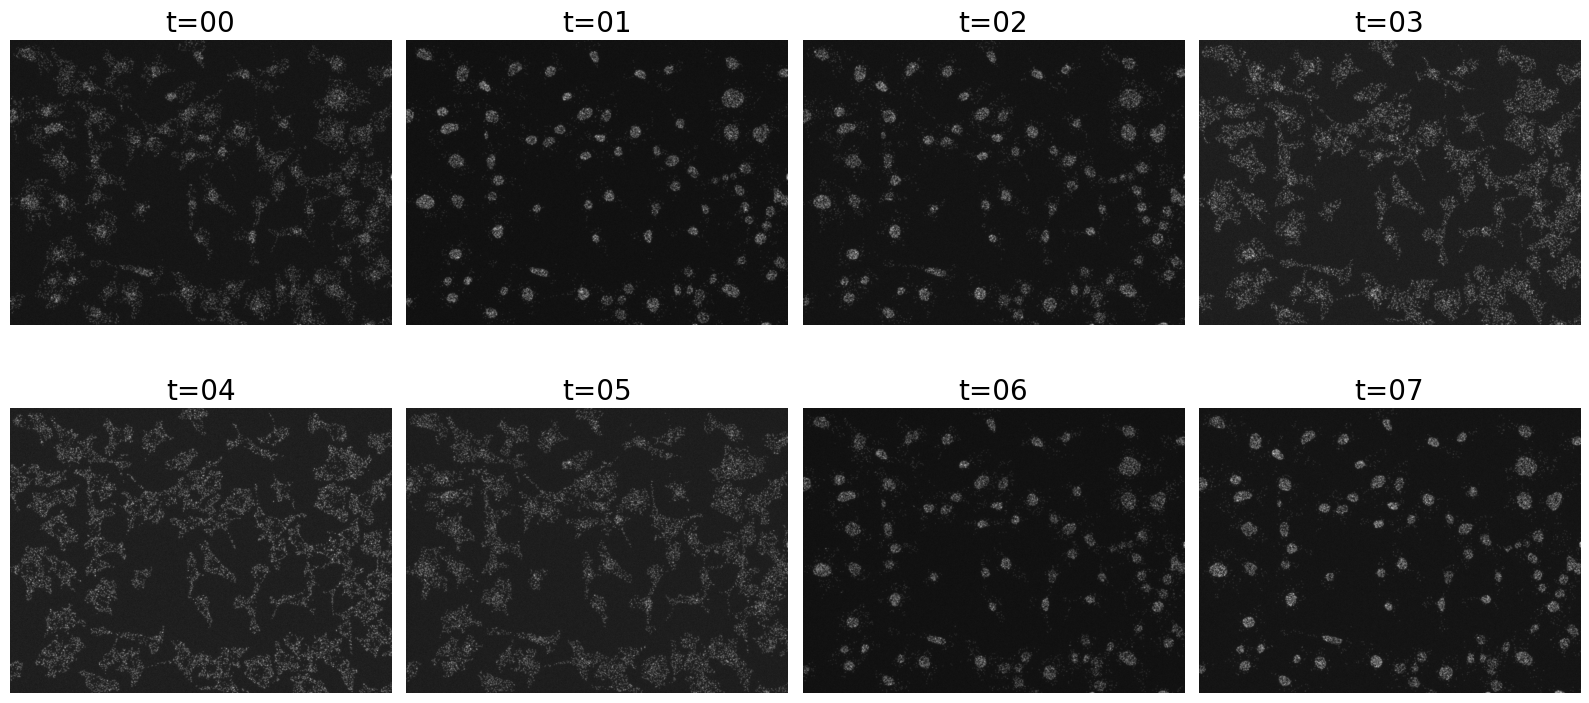

In [36]:
image_folder = Path("https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/quant/03_time_series/images/")
image_paths = sorted(image_folder.glob("*.tif"))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, path in zip(axes.flat, image_paths[:8]):
    image = tifffile.imread(path)
    tp = path.stem.split("_t")[1].split("_")[0]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"t={tp}", fontsize=20)
    ax.axis("off")

plt.tight_layout()
plt.show()


These are the first eight time points.

(<Figure size 800x800 with 1 Axes>, <Axes: >)

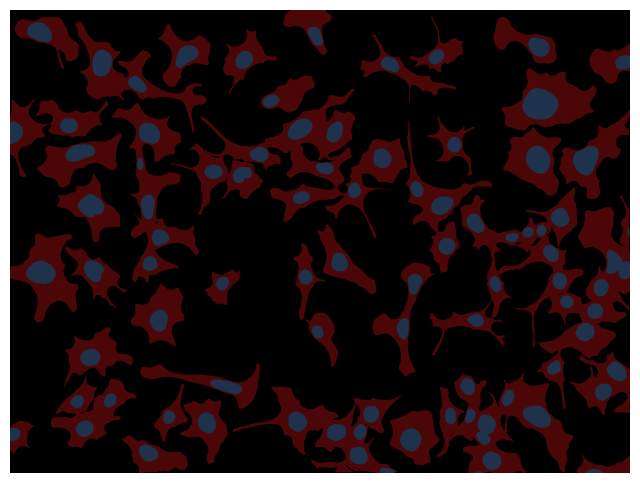

In [27]:
mask_cells = tifffile.imread('https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/quant/03_time_series/masks/F01_202_cells.TIF')
mask_nuclei = tifffile.imread('https://raw.githubusercontent.com/bobiac/bobiac-book/main/_static/images/quant/03_time_series/masks/F01_202_nuclei.TIF')

overlay(label_mask=[mask_cells, mask_nuclei])

This are the two label masks for the nuclei and the cells.

### ✍️ Exercise: Perfom this analysis

1. For the first time point (image) use `regionprops_table` to measure the expression level of each nucleus. Follow the steps of the previous notebooks.
2. Perform proper quality control and check that the measurements do not contain artefacts.
3. Set up batch processing to analyse all 16 images. Remember to keep track of where the data came from. Add a column `time` that contains the time at which the image was taken (e.g. 0, 0.5, 1, 1.5) (the unit is hours).
4. Use `sns.lineplot` to visualise the oscillations of individual cell as well as the average oscillations, and estimate the frequency.
5. BONUS: Instead of nuclear intensity, calculate the ratio of nuclear/cytoplasmic intensity.

## Solution

### 1. Measure nuclear intensity
First, we measure the intesities of all the nuclei in the image.

Load the first time point.

(<Figure size 800x800 with 1 Axes>, <Axes: >)

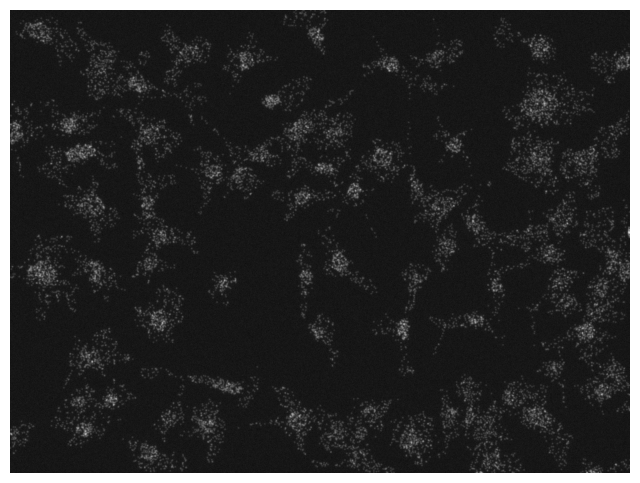

In [35]:
image_path = image_paths[0]

image_t0 = tifffile.imread(image_path)
overlay(image=image_t0)

Remove boundary objects.

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

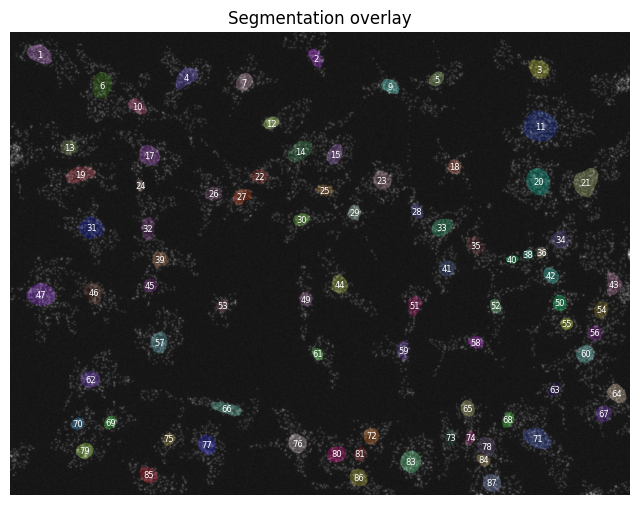

In [29]:
mask_nuclei = skimage.segmentation.clear_border(mask_nuclei)
overlay(image=image_t0, label_mask=mask_nuclei)

Measure intesities with `regionprops_table` ans save measurements as `DataFrame`.

In [31]:
properties = [
    "area",
    "intensity_mean",
    "label"
]
props = skimage.measure.regionprops_table(
    mask_nuclei, intensity_image=image_t0, properties=properties
)

df_nuc = pd.DataFrame(props)
print(df_nuc)

      area  intensity_mean  label
0   1837.0    14939.234077      1
1    985.0    16847.844670      2
2   1578.0    15244.809886      3
3   1715.0    12532.597085      4
4    880.0    13569.377273      5
..     ...             ...    ...
77  1883.0    14892.003717     83
78   640.0    10716.570312     84
79  1225.0    15343.338776     85
80  1275.0    11251.812549     86
81  1350.0    13318.067407     87

[82 rows x 3 columns]


Subtract background intensity from measurements. Background was measured to 4700.

In [32]:
background_intensity = 4700
df_nuc['intensity_bg_cor'] = df_nuc['intensity_mean'] - background_intensity

Add `time` column.

In [41]:
time_point = image_path.stem.split('_')[2]
time = float(time_point[1:]) * 0.5
print(time)

0.0


In [ ]:
df_nuc['time'] = time

### 2. Quality control

<Axes: xlabel='intensity_bg_cor', ylabel='Count'>

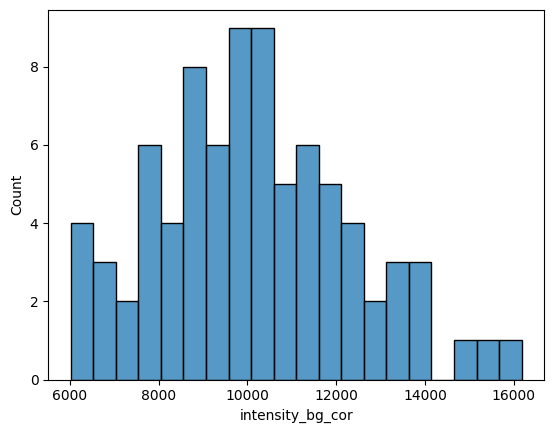

In [43]:
sns.histplot(
    data=df_nuc,
    x='intensity_bg_cor',
    bins=20,
)

Seems unsuspicious.

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_2590/359609334.py:115: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_2590/359609334.py:146: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'intensity_bg_cor'}>)

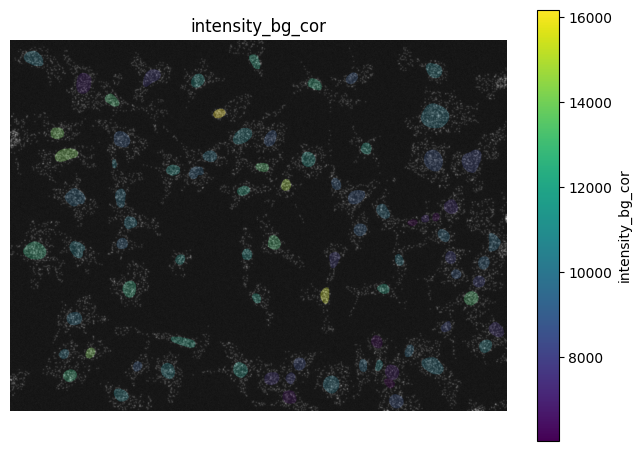

In [45]:
overlay(image=image_t0, label_mask=mask_nuclei, df=df_nuc, id_col='label', measurement_col='intensity_bg_cor')

Looks fine.

### Batch processing

In [46]:
list_df = []

for image_path in image_paths:
    image = tifffile.imread(image_path)
    props = skimage.measure.regionprops_table(
        mask_nuclei, 
        intensity_image=image, 
        properties=properties
    )
    sdf = pd.DataFrame(props)
    sdf['intensity_bg_cor'] = sdf['intensity_mean'] - background_intensity
    time_point = image_path.stem.split('_')[2]
    time = float(time_point[1:]) * 0.5
    sdf['time'] = time
    list_df.append(sdf)

df = pd.concat(list_df)
print(df)

      area  intensity_mean  label  intensity_bg_cor  time
0   1837.0    14939.234077      1      10239.234077   0.0
1    985.0    16847.844670      2      12147.844670   0.0
2   1578.0    15244.809886      3      10544.809886   0.0
3   1715.0    12532.597085      4       7832.597085   0.0
4    880.0    13569.377273      5       8869.377273   0.0
..     ...             ...    ...               ...   ...
77  1883.0    10872.139140     83       6172.139140   7.5
78   640.0    10264.109375     84       5564.109375   7.5
79  1225.0    11034.377959     85       6334.377959   7.5
80  1275.0    10043.316863     86       5343.316863   7.5
81  1350.0    10865.971852     87       6165.971852   7.5

[1312 rows x 5 columns]


### Plotting

In [50]:
df.groupby(['label', 'time'])['intensity_bg_cor'].mean().reset_index()

,label,time,intensity_bg_cor
0,1,0.0,10239.234077
1,1,0.5,11754.823081
2,1,1.0,10902.924878
3,1,1.5,9079.529124
4,1,2.0,5051.951007
...,...,...,...
1307,87,5.5,11085.093333
1308,87,6.0,9564.538519
1309,87,6.5,8208.691111
1310,87,7.0,6148.278519


<Axes: xlabel='time', ylabel='intensity_bg_cor'>

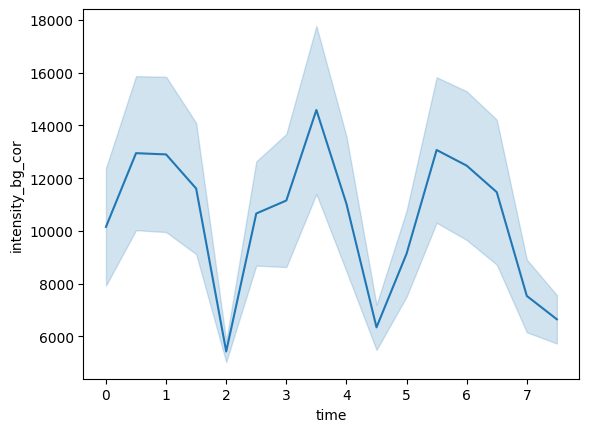

In [60]:
sns.lineplot(
    data=df,
    x='time',
    y='intensity_bg_cor',
    errorbar='sd'
)

<Axes: xlabel='time', ylabel='intensity_bg_cor'>

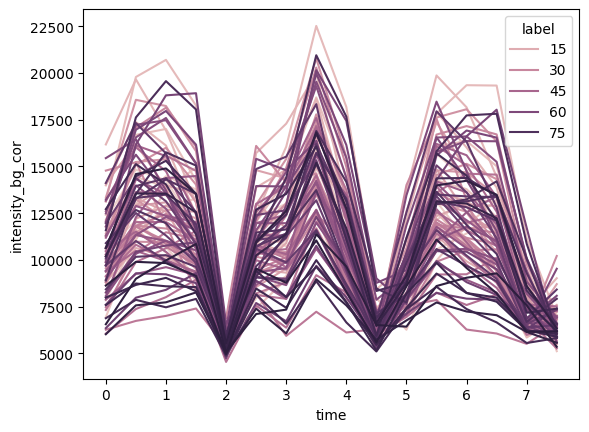

In [59]:
sns.lineplot(
    data=df,
    x='time',
    y='intensity_bg_cor',
    hue='label'
)